In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.chdir("..")
print(os.getcwd(), os.listdir())

C:\Users\an.v.potapov\Desktop\учеба\ФТИАД\курсач\gan_moex ['.git', '.gitignore', '.idea', '.ipynb_checkpoints', '.pytest_cache', 'AIRI', 'compare with airi', 'dashboard', 'data', 'genrisk', 'library', 'lightning_logs', 'models', 'README.MD', 'research', 'setup.py', 'test.egg-info', 'TSGBench', 'wandb']


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import DataLoader
import seaborn as sns
from torch import optim
import torch
import wandb


In [4]:
from library.dataset import get_pytorch_datataset, BATCH_SIZE

df_returns_real, dataset, dataloader, N_ASSETS, WINDOW_SIZE = get_pytorch_datataset()

print(f'\nDataset length: {len(dataset)}')
print(f'Number of assets: {N_ASSETS}')
sample_batch = next(iter(dataloader))
assert sample_batch.size() == (BATCH_SIZE, N_ASSETS, WINDOW_SIZE)
print(f'Sample batch: {sample_batch.size()}')

AAAAAAA data True data\tickers.csv True
Chosen tickers: ['LKOH', 'SBER', 'SBERP', 'VTBR', 'MOEX']
Length before dropping NaNs: 2603
Length after dropping NaNs: 2577

Dataset length: 2451
Number of assets: 5
Sample batch: torch.Size([256, 5, 126])


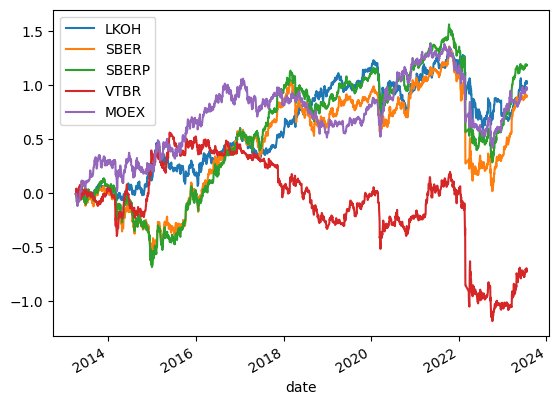

In [5]:
df_returns_real.cumsum().plot()
plt.show()

In [7]:
from genrisk.generation import TCNGAN

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Python\Lib\site-packages\lightning\pytorch\loggers\wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.

  | Name | Type              | Params | Mode 
---------------------------------------------------
0 | gen  | _TCNGenerator     | 2.5 K  | train
1 | disc | _TCNDiscriminator | 2.7 K  | train
---------------------------------------------------
5.3 K     Trainable params
0         Non-trainable params
5.3 K     Total params
0.021     Total estimated model params size (MB)
24        Modules in train mode
0         Modules in eval mode


Training: |                                                                                                 | …

`Trainer.fit` stopped: `max_epochs=5` reached.


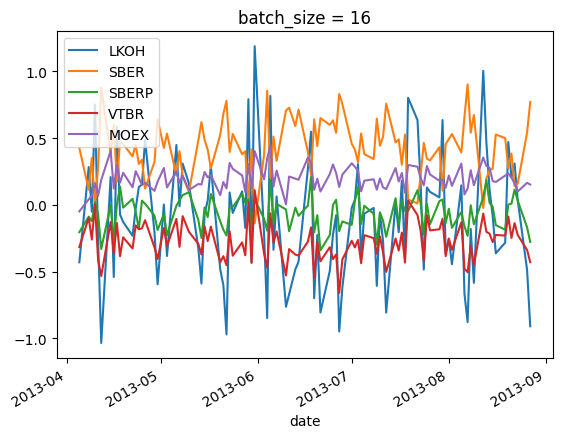

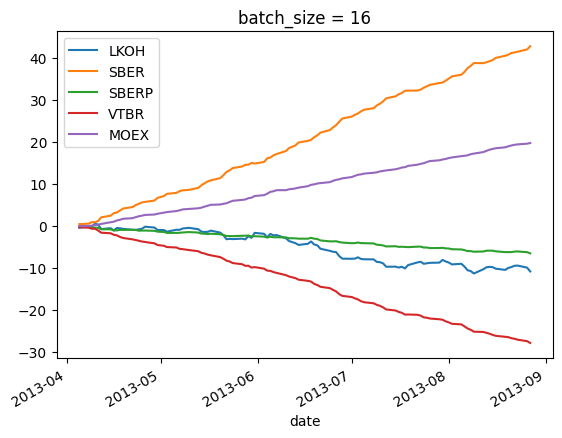

correlation_delta,██▇▇▆▅▅▅▅▄▄▄▃▂▂▂▂▂▂▁▁▂▁▂▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▆
epoch,▁▁▁▁▁▁▁▁▃▃▃▃▃▃▃▃▅▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆████████
fid,█▇▇▅▅▅▆▄▄▃▃▃▃▃▃▂▂▁▁▁▂▂▂▂▂▃▃▃▃▃▄▃▄▄▅▅▄▄▅▆
mean_delta,██▇▇▇▆▅▄▄▃▂▂▁▁▁▂▁▂▂▁▂▂▂▂▃▃▂▂▂▂▃▃▃▃▄▄▅▄▅▅
train_disc_loss,▂▂▂▁▁▁▁▁▁▁▂▂▂▂▂▃▃▃▄▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇█████
train_gen_loss,██████████▇▇▇▇▆▆▆▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁
trainer/global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
correlation_delta,0.35168
epoch,4
fid,3.93858
mean_delta,0.20534


In [12]:
N_EPOCHS = 5
window_size = 360

for BATCH in ([16]):
    wandb.init(
                project="gan_moex",  # Название проекта в W&B
                name=f"AIRI генерация log доходности акций",         # AIRI генерация log доходности акций
                
                config={              # Сохраняем гиперпараметры
                    "learning_rate": 0.001,
                    "batch_size": BATCH,
                    "architecture": "TCN-GAN AIRI",
                    "dataset": 'log-returs',
                    "N_EPOCHS": N_EPOCHS,
                }
            )
    
    gen = TCNGAN(
        target_columns=df_returns_real.columns.tolist(), 
        conditional_columns=[],
        hidden_dim=16,
        latent_dim=1,
        num_layers=2,
        kernel_size=3,
        num_disc_steps=3,
        window_size=window_size,
        batch_size=BATCH,
        num_epochs=N_EPOCHS,
        verbose=True,
        lr=0.001,
    )
    gen.fit(df_returns_real)

    fake_data = gen.sample(df_returns_real.iloc[:100], n_samples=1)
    
    fake_data[0].plot()
    
    plt.title(f'batch_size = {BATCH}')
    wandb.log({"generated_samples": wandb.Image(plt)})
    plt.show()
    
    fake_data[0].cumsum().plot()
    
    plt.title(f'batch_size = {BATCH}')
    wandb.log({"cumsum_generated_samples": wandb.Image(plt)})
    plt.show()

    
    wandb.finish()

In [9]:
fake_data = gen.sample(df_returns_real, n_samples=10)
fake_data[0].head()

,LKOH,SBER,SBERP,VTBR,MOEX
date,,,,,
2013-04-05,0.067366,0.351358,-0.064038,0.175481,0.374686
2013-04-08,0.259969,0.273771,-0.049847,-0.051569,0.398581
2013-04-09,0.159042,0.234306,-0.070234,0.020737,0.430525
2013-04-10,0.107999,0.196515,-0.058914,-0.012649,0.351933
2013-04-11,0.120014,0.210781,-0.089339,0.065880,0.451478


<Figure size 1200x300 with 0 Axes>

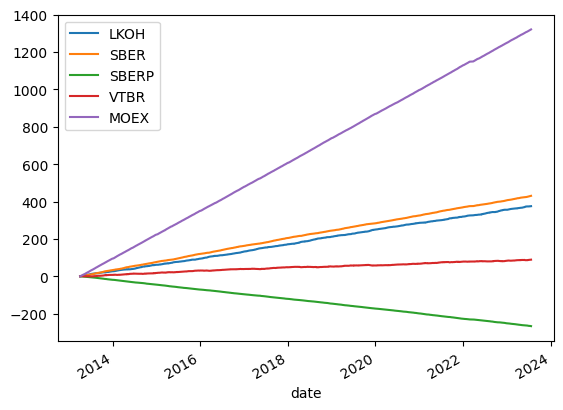

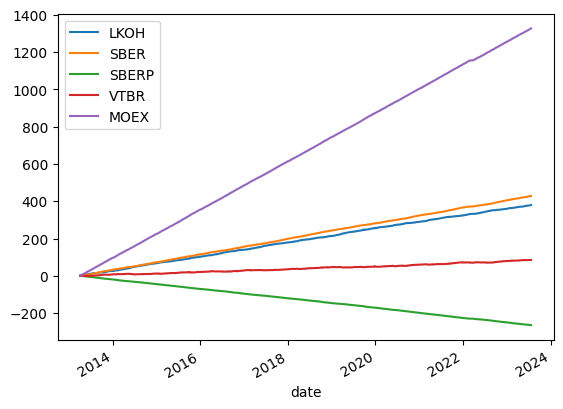

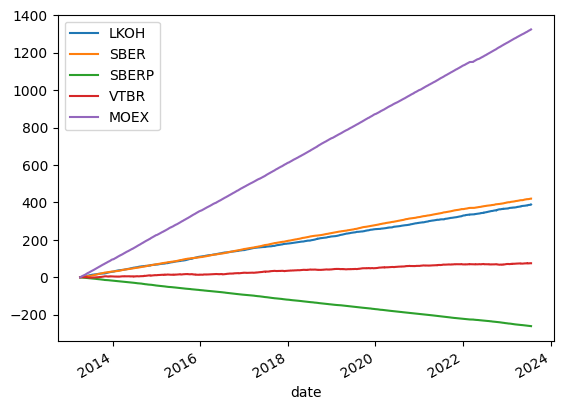

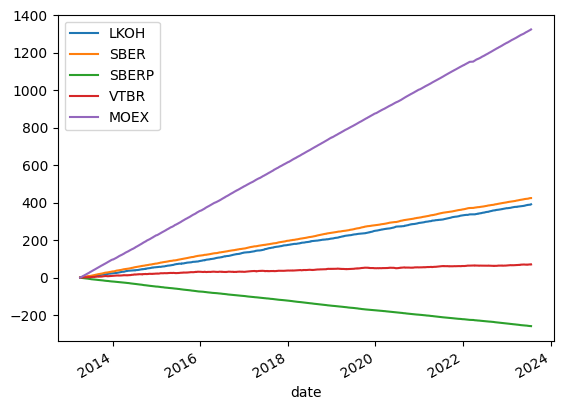

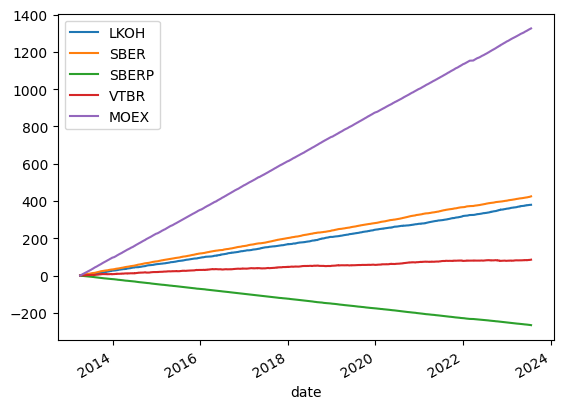

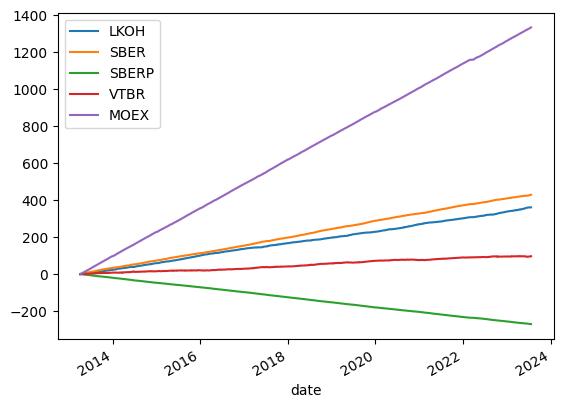

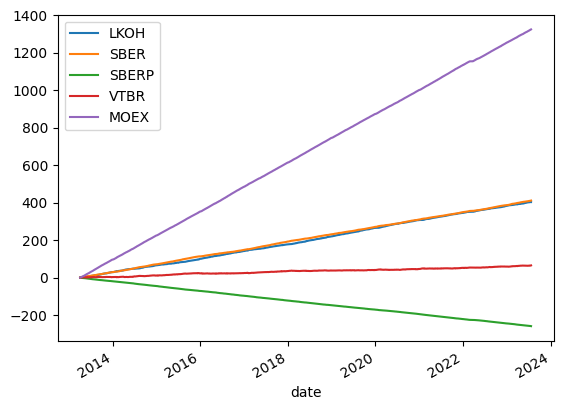

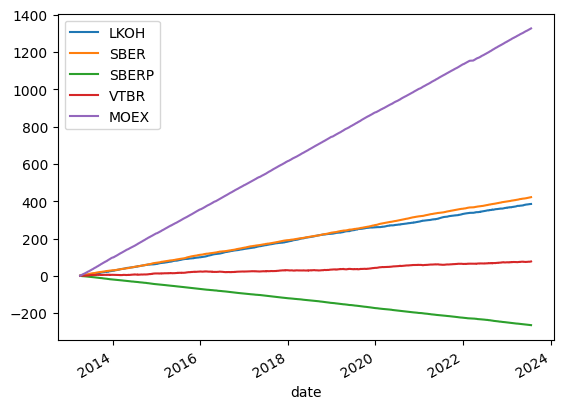

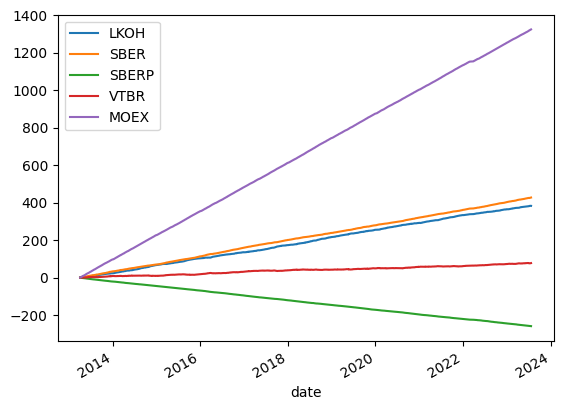

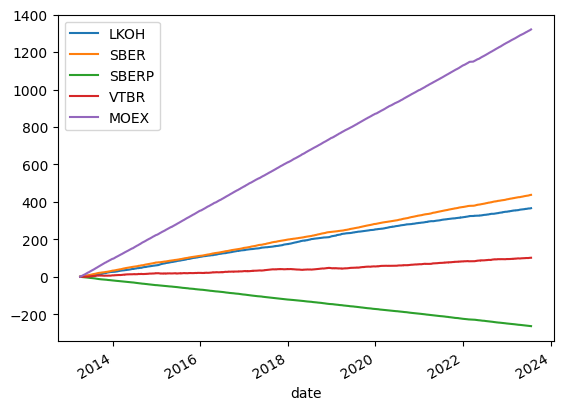

In [10]:
plt.figure(figsize=(12, 3))
for fake in fake_data:
    fake.cumsum().plot()


<Axes: xlabel='date'>

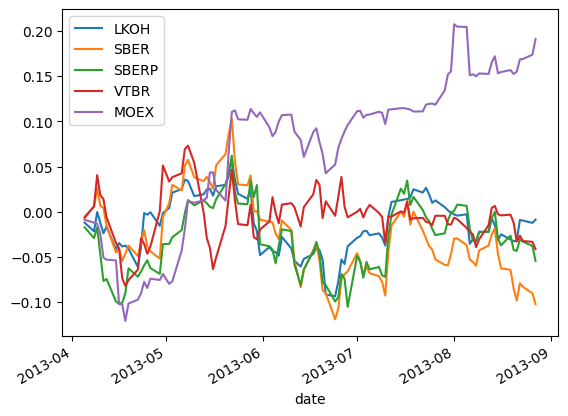

In [32]:
df_returns_real.iloc[:100].cumsum().plot()

In [8]:
torch.abs(torch.rand(3, 4, 5)[-1].corrcoef()).sum()

tensor(7.0182)

In [29]:
torch.abs(torch.rand(3, 4, 5).mean(axis=1))

tensor([[0.5533, 0.3956, 0.6158, 0.5669, 0.5612],
        [0.4262, 0.6352, 0.4849, 0.4541, 0.2660],
        [0.2210, 0.4104, 0.3990, 0.4670, 0.5107]])

In [11]:
torch.tensor([1, 2, 3]).detach().to_numpy()

AttributeError: 'Tensor' object has no attribute 'to_numpy'

In [20]:
# for i in (1, 2, 3, 4):
#     print(calculate_fid(sample_batch[-1].transpose(1, 0), sample_batch[i].transpose(1, 0)))
from dashboard.fid import calculate_fid
calculate_fid(sample_batch[-1].transpose(1, 0), torch.rand(126, 5))

torch.Size([126, 5])


13.731320295642748

In [31]:

wandb.finish()

In [19]:
torch.save(gen.model.gen.state_dict(), 'models/AIRI/TCN/test_save.pth')


In [9]:
wandb.init(
        project="test",  # Название проекта в W&B
        name=f"AIRI генерация log доходности акций",         # Название эксперимента
        
        config={              # Сохраняем гиперпараметры
            "learning_rate": 0.001,
            "batch_size": 0,
            "architecture": "TCN-GAN AIRI",
            "dataset": 'log-returs',
            "N_EPOCHS": 1,
        }
    )

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: avpotapov_5 (avpotapov_5-hse) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [10]:

    
test_model = TCNGAN(
    target_columns=df_returns_real.columns.tolist(), 
    conditional_columns=[],
    hidden_dim=16,
    latent_dim=1,
    num_layers=2,
    kernel_size=3,
    num_disc_steps=3,
    window_size=126,
    batch_size=16,
    num_epochs=1,
    verbose=True,
    lr=0.001,
)
test_model.fit(df_returns_real)
wandb.finish()

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Python\Lib\site-packages\lightning\pytorch\loggers\wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.

  | Name | Type              | Params | Mode 
---------------------------------------------------
0 | gen  | _TCNGenerator     | 2.5 K  | train
1 | disc | _TCNDiscriminator | 2.7 K  | train
---------------------------------------------------
5.3 K     Trainable params
0         Non-trainable params
5.3 K     Total params
0.021     Total estimated model params size (MB)
24        Modules in train mode
0         Modules in eval mode


Training: |                                                                                                 | …

`Trainer.fit` stopped: `max_epochs=1` reached.


correlation_delta,▆▂▅▂▇█▅▁▅
epoch,▁▁▁▁▁▁▁▁▁
fid,▄▅▅▁▄▁▃█▄
mean_delta,▆▆▆▇█▄▄▃▁
train_disc_loss,▂▁▂▂▃▃▅▇█
train_gen_loss,▁▃▃▅▅▆▇▇█
trainer/global_step,▁▂▃▄▅▅▆▇█
correlation_delta,0.83543
epoch,0
fid,6.50645
mean_delta,0.22838


In [12]:
# torch.save(gen.model.gen.state_dict(), '')
test_model.model.gen.load_state_dict(torch.load('models/AIRI/TCN/test_save.pth'))

<All keys matched successfully>

In [14]:

fake_data = test_model.sample(df_returns_real, n_samples=10)
fake_data[0].head()

,LKOH,SBER,SBERP,VTBR,MOEX
date,,,,,
2013-04-05,0.016270,-0.035804,0.015416,0.066307,0.053003
2013-04-08,-0.005711,-0.028314,0.013687,0.031832,0.014898
2013-04-09,0.014258,0.003238,0.035848,-0.006480,-0.002224
2013-04-10,0.011610,-0.005799,0.018235,-0.000902,-0.007754
2013-04-11,0.003941,0.040849,0.016328,-0.009477,-0.010623


<Figure size 1200x300 with 0 Axes>

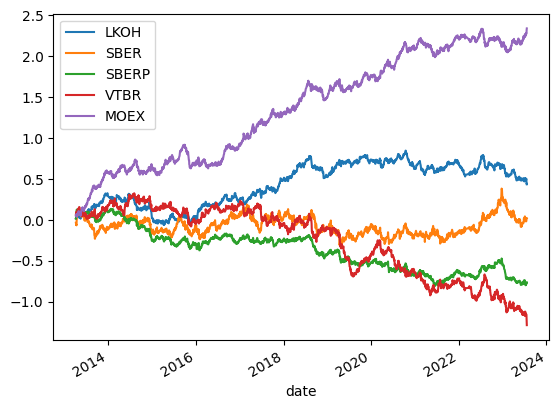

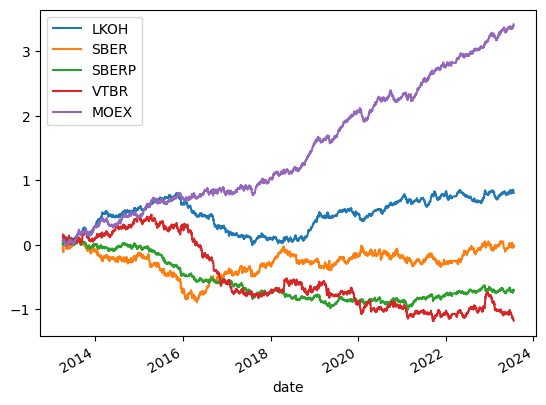

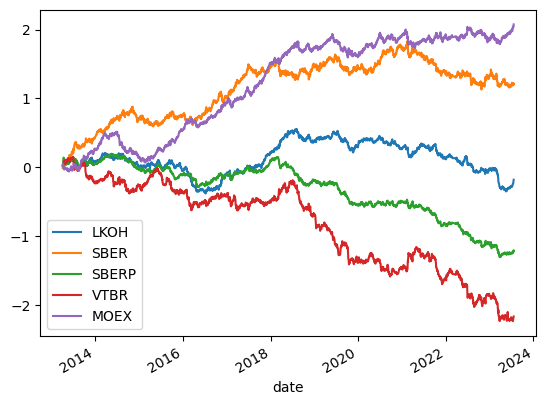

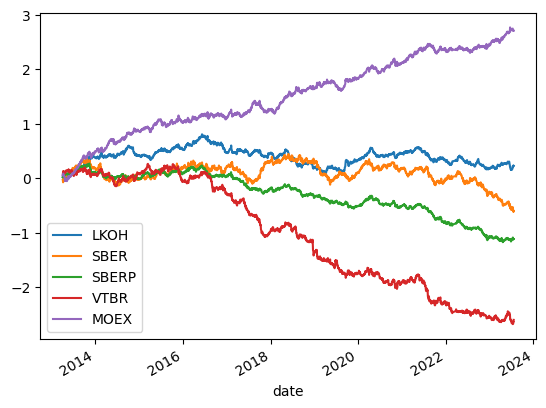

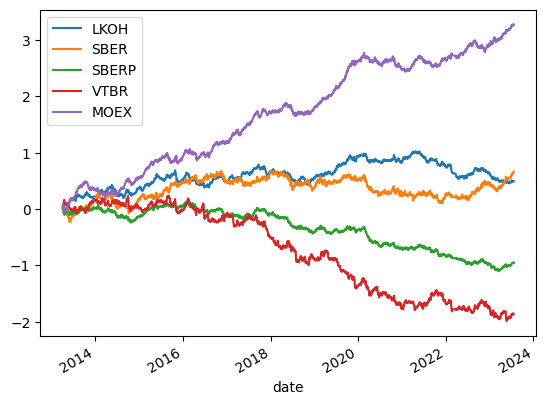

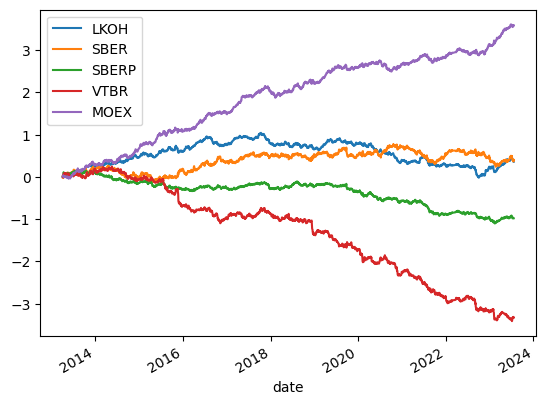

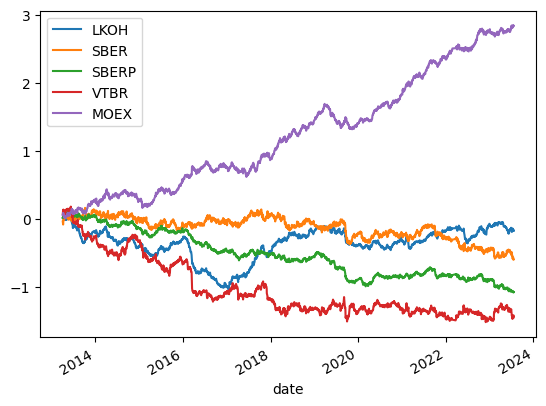

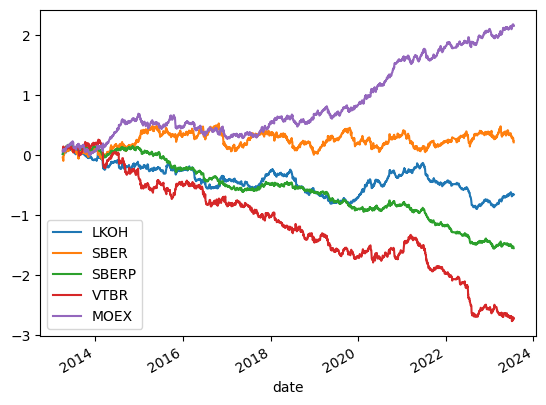

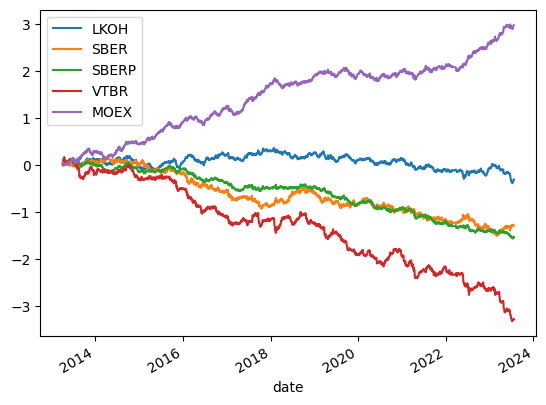

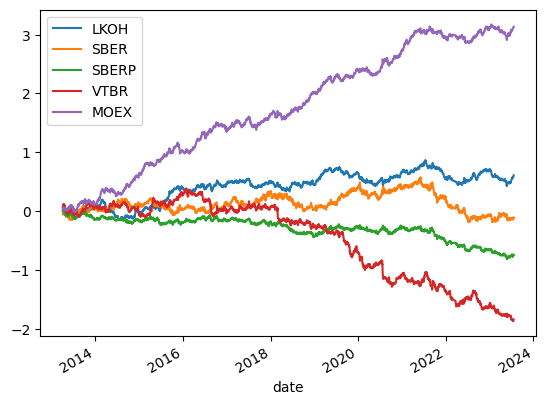

In [15]:
plt.figure(figsize=(12, 3))
for fake in fake_data:
    fake.cumsum().plot()


In [20]:
import torch
import torch.nn.functional as F

def vectorized_windowed_autocorrelation(x, lag, window_size):
    """
    Вычисляет автокорреляцию с лагом `lag` в скользящем окне `window_size`
    для каждого актива в 3D-тензоре.
    
    Args:
        x: torch.Tensor, shape (batch_size, num_assets, seq_len)
        lag: int, лаг автокорреляции (должен быть < window_size)
        window_size: int, размер скользящего окна
    
    Returns:
        autocorr: torch.Tensor, shape (batch_size, num_assets, seq_len - window_size + 1)
    """
    if lag >= window_size:
        raise ValueError("Lag must be less than window size.")
    if window_size > x.size(2):
        raise ValueError("Window size must be less than sequence length.")
    
    # Центрируем данные
    x_centered = x - x.mean(dim=2, keepdim=True)
    
    # Создаем sliding windows с помощью unfold
    # x_unfolded shape: (batch_size, num_assets, window_size, num_windows)
    x_unfolded = F.unfold(
        x_centered.unsqueeze(3), 
        kernel_size=(window_size, 1),
        stride=(1, 1)
    ).view(x.size(0), x.size(1), window_size, -1)
    
    # Разделяем на x[t] и x[t+lag] в каждом окне
    x_t = x_unfolded[:, :, :-lag, :]       # (batch_size, num_assets, window_size-lag, num_windows)
    x_t_lag = x_unfolded[:, :, lag:, :]     # (batch_size, num_assets, window_size-lag, num_windows)
    
    # Вычисляем ковариацию и стандартные отклонения
    cov = (x_t * x_t_lag).mean(dim=2)      # (batch_size, num_assets, num_windows)
    std_t = x_t.std(dim=2, unbiased=False)  # (batch_size, num_assets, num_windows)
    std_t_lag = x_t_lag.std(dim=2, unbiased=False)  # (batch_size, num_assets, num_windows)
    
    # Автокорреляция
    eps = 1e-8
    autocorr = cov / (std_t * std_t_lag + eps)
    
    return autocorr
def vectorized_windowed_autocorrelation_avg(x, lag, window_size):
    """
    Вычисляет усредненную автокорреляцию с лагом `lag` в скользящем окне `window_size`
    для каждого актива в 3D-тензоре.
    
    Args:
        x: torch.Tensor, shape (batch_size, num_assets, seq_len)
        lag: int, лаг автокорреляции
        window_size: int, размер скользящего окна
    
    Returns:
        autocorr_avg: torch.Tensor, shape (batch_size, num_assets)
    """
    # Вычисляем автокорреляцию для всех окон
    autocorr = vectorized_windowed_autocorrelation(x, lag, window_size)  # (batch_size, num_assets, num_windows)
    
    # Усредняем по всем окнам для каждого актива в батче
    autocorr_avg = autocorr.mean(dim=2)  # (batch_size, num_assets)
    
    return autocorr_avg

In [22]:
batch_size, num_assets, seq_len = 32, 5, 100  # 5 активов, 100 временных шагов
x = torch.randn(batch_size, num_assets, seq_len)  # Случайные данные
lag = 3  # Лаг автокорреляции

autocorr = vectorized_windowed_autocorrelation_avg(x, lag, 10)
print(autocorr)  # torch.Size([32, 5])

tensor([[-0.0613,  0.0347,  0.3272, -0.0520, -0.1051],
        [ 0.0396, -0.0719,  0.0337,  0.0255, -0.0403],
        [ 0.0015,  0.0753,  0.0079, -0.0106,  0.1278],
        [-0.0846,  0.0223, -0.0353,  0.1419,  0.2473],
        [ 0.1615,  0.0394,  0.0451,  0.0837,  0.0888],
        [ 0.2701,  0.0632,  0.0153, -0.0051,  0.0048],
        [ 0.0384,  0.1809,  0.3090,  0.1244,  0.0039],
        [-0.0441, -0.2258,  0.0779,  0.1665, -0.0100],
        [ 0.1796,  0.0804, -0.0204,  0.0044,  0.1787],
        [-0.1676,  0.4305,  0.1539,  0.0426, -0.0446],
        [-0.0163,  0.0699, -0.0318, -0.0424,  0.0614],
        [ 0.2883, -0.2041,  0.0356, -0.0870, -0.1587],
        [-0.0433,  0.1204, -0.0709,  0.1111, -0.0352],
        [-0.0035,  0.5477, -0.2578,  0.5942,  0.2169],
        [ 0.0170,  0.0239,  0.0948,  0.0463, -0.0300],
        [-0.1766,  0.1570,  0.1536,  0.0122,  0.2916],
        [ 0.2125, -0.0931,  0.0860,  0.1142,  0.0456],
        [-0.0118, -0.1175,  0.0829,  0.0383, -0.1616],
        [ 

In [16]:
autocorr[0]

tensor([-0.0461,  0.0438, -0.0304, -0.1574, -0.0992])